In [1]:
!pip install -q -U biopython datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.6 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

ds = load_dataset("tattabio/modac_paralogy_bigene")
print(ds)

README.md:   0%|          | 0.00/370 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/996k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1492 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID1', 'Seq1', 'ID2', 'Seq2'],
        num_rows: 1492
    })
})


In [3]:
import pandas as pd

df = pd.DataFrame(ds["train"])

print(df.head())
print(df.columns.tolist())
print(f"Total rows: {len(df)}")

      ID1                                               Seq1     ID2  \
0  E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1  D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2  C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3  C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4  C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   

                                                Seq2  
0  MPSRTRLRMSDKSRNWYLIPYTAWIVLFVVAPIALVVYYSLFDIEG...  
1  MRRLSSRSRAKALKALRLTVSYLVLIVMAAWSILPIYYIILISFSN...  
2  MQRRFWWCSGGLVAALILSATLGPLAALLSQPGTTTVLLWQDSYLT...  
3  MAVVRHRRWLAGSGALALLLFSPVMALLIEAFSTDAGLLQQLWQTV...  
4  MTEQDWSTVWLTLKLALLVTGILLLIATPLAWWLAQTRSRYKPLFN...  
['ID1', 'Seq1', 'ID2', 'Seq2']
Total rows: 1492


In [4]:
correct_pairs = dict(zip(df["ID1"], df["ID2"]))

print(list(correct_pairs.items())[:5])

[('E0I7Z3', 'E0I7Z2'), ('D9PZK5', 'D9PZK6'), ('C4LAU3', 'C4LAU4'), ('C4LAH6', 'C4LAH7'), ('C4L8Q6', 'C4L8Q7')]


In [5]:
def write_fasta(ids, seqs, filename):
    with open(filename, "w") as f:
        for seq_id, seq in zip(ids, seqs):
            f.write(f">{seq_id}\n{seq}\n")

# Query proteins (ModA)
write_fasta(
    df["ID1"],
    df["Seq1"],
    "modA.fasta"
)

# Database proteins (ModC)
write_fasta(
    df["ID2"],
    df["Seq2"],
    "modC.fasta"
)

print("FASTA files created successfully")

FASTA files created successfully


In [ ]:
!apt-get install ncbi-blast+ -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 2s (9,153 kB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb .

In [ ]:
!makeblastdb -in modC.fasta -dbtype prot -out modC_db



Building a new DB, current time: 04/29/2026 01:18:20
New DB name:   /content/modC_db
New DB title:  modC.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 1492 sequences in 0.032285 seconds.




In [ ]:
!blastp \
-query modA.fasta \
-db modC_db \
-outfmt "6 qseqid sseqid evalue bitscore pident" \
-out blast_results.txt \
-max_target_seqs 50 \
-evalue 10

In [ ]:
blast_df = pd.read_csv(
    "blast_results.txt",
    sep="\t",
    names=["query", "subject", "evalue", "bitscore", "pident"]
)

print(blast_df.head())
print(f"Total BLAST hits: {len(blast_df)}")

    query subject        evalue  bitscore  pident
0  E0I7Z3  D8FZG1  3.890000e-40     146.0  41.176
1  E0I7Z3  Q3A658  6.200000e-01      27.7  30.189
2  D9PZK5  D8FZG1  4.050000e-30     117.0  32.500
3  D9PZK5  G5F5B2  4.000000e+00      25.0  30.612
4  C4LAU3  D8FZG1  5.760000e-25      98.6  38.983
Total BLAST hits: 6186


In [ ]:
def recall_at_k(blast_df, correct_pairs, k=50):
    total = 0
    correct = 0

    for query_id, group in blast_df.groupby("query"):
        if query_id not in correct_pairs:
            continue

        total += 1

        top_k = group.sort_values("evalue").head(k)

        if correct_pairs[query_id] in top_k["subject"].values:
            correct += 1

    return correct / total if total > 0 else 0

recall = recall_at_k(blast_df, correct_pairs, k=50)

print(f"BLAST Recall@50 = {recall:.4f}")

BLAST Recall@50 = 0.0027


In [ ]:
print(df.head(10))
print(df.iloc[0])
print(df["ID1"].nunique())
print(df["ID2"].nunique())

      ID1                                               Seq1     ID2  \
0  E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1  D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2  C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3  C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4  C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
5  C4LFF5  MSSAIEIRNLTKRYNDLTILDDISFSIEPSEFIVFLGPSGCGKSTL...  C4LFF4   
6  I6ASA2  MSETRPPMIEINGVTKRFGSFTAVNRVSLQVHAGEFITLLGPSGCG...  I6ASA1   
7  I6B401  MSSSAMSATSGNETASPQPATTTPPSRAGHLQVSGVSRHFAPGAGG...  I6B402   
8  H3KAB9  MALEVAIKKYYPDFSLDVNFYTEKGILGVLGASGCGKSMTLKCIAG...  H3KAB8   
9  C1ABQ1  MSIDTNTATNTGMEGAREASNPVLDVTIRRRLPTFELDIAFRIHNG...  C1ABQ0   

                                                Seq2  
0  MPSRTRLRMSDKSRNWYLIPYTAWIVLFVVAPIALVVYYSLFDIEG...  
1  MRRLSSRSRAKALKALRLTVSYLVLIVMAAWSILPIYYIILISFSN...  
2  MQRRFWWCSGGLVAALILSATLGPLAALLSQPGTTTVLL

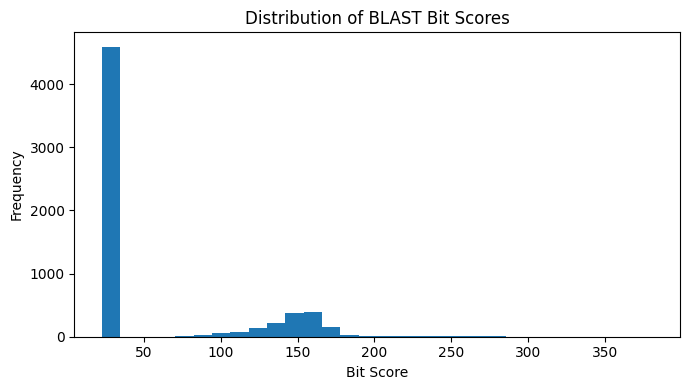

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(blast_df["bitscore"], bins=30)
plt.xlabel("Bit Score")
plt.ylabel("Frequency")
plt.title("Distribution of BLAST Bit Scores")
plt.tight_layout()
plt.show()

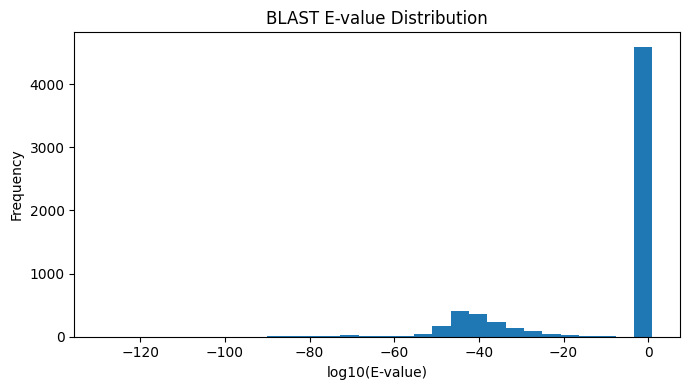

In [ ]:
import numpy as np

plt.figure(figsize=(7,4))
plt.hist(np.log10(blast_df["evalue"] + 1e-200), bins=30)
plt.xlabel("log10(E-value)")
plt.ylabel("Frequency")
plt.title("BLAST E-value Distribution")
plt.tight_layout()
plt.show()

##Match person A

In [1]:
!pip install -q -U biopython datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.3 MB/s eta 0:00:00


In [2]:
!apt-get update
!apt-get install ncbi-blast+ -y

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,993 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Hit:11 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Pa

In [3]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("tattabio/modac_paralogy_bigene")
df = pd.DataFrame(ds["train"])

# positive pairs
pos_df = df.copy()
pos_df["label"] = 1

# negative pairs (same logic as Person A)
neg_df = df.copy()
neg_df["Seq2"] = df["Seq2"].sample(frac=1, random_state=42).values
neg_df["ID2"] = df["ID2"].sample(frac=1, random_state=42).values
neg_df["label"] = 0

pair_df = pd.concat([pos_df, neg_df], ignore_index=True)
pair_df = pair_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(pair_df.head())

README.md:   0%|          | 0.00/370 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/996k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1492 [00:00<?, ? examples/s]

      ID1                                               Seq1     ID2  \
0  A6W3C3  MDSSVHLDNTIMQFGEFTAIQQTDLTIKSGEFFSFLGPSGCGKTTI...  A8MJ34   
1  F1VVC5  MALLELQDVNYAYGAQKVVEELSLRLAPGAIGCLLGPSGCGKTTVL...  F8DA07   
2  A8ZS02  MNHAHLQVDGLTLSLGGFCLRDIHLLCAKGEYHVLLGPTGSGKTSL...  A8ZS01   
3  H9U9X7  MPGSSVSIVNVDKYFGDFHVLKNINLEIKENEFFSLLGPSGCGKTT...  H9U9X8   
4  C4IB29  MSLYVDIEKQFSSFKLKVNFESRNEVLGLLGESGSGKSITLKCISG...  D5UD59   

                                                Seq2  label  
0  MNIDLSPLIISLKTSLVAVFFTFILGIVAARCMLHASGKVQWILDV...      0  
1  MSRHSNTNTNAAAQSASESRRLPVALERGLPALDGATLRAHAGLLL...      0  
2  MNRVFDAIIWGTAGLLILAFIGLFAGMLVELGQEKVLSSPDLGRVL...      1  
3  MSRKKHIRPLSRGYESYGLVYLLWLAVFFLIPVIVILTYSFFERDY...      1  
4  MSVLTALARPERTPGPGAGTPPTAARRGHRRLLLPGLVYLVAFFLV...      0  


In [4]:
import subprocess
import tempfile
import os

def blast_pair(seq1, seq2):
    with tempfile.NamedTemporaryFile(mode="w", delete=False) as qf:
        qf.write(">query\n" + seq1 + "\n")
        query_file = qf.name

    with tempfile.NamedTemporaryFile(mode="w", delete=False) as sf:
        sf.write(">subject\n" + seq2 + "\n")
        subject_file = sf.name

    out_file = tempfile.NamedTemporaryFile(delete=False).name

    cmd = [
        "blastp",
        "-query", query_file,
        "-subject", subject_file,
        "-outfmt", "6 bitscore evalue pident"
    ]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.stdout.strip():
            lines = result.stdout.strip().split("\n")
            first_line = lines[0]   # take best hit

            bitscore, evalue, pident = first_line.split("\t")

            bitscore = float(bitscore)
            evalue = float(evalue)
            pident = float(pident)
        else:
            bitscore, evalue, pident = 0.0, 1.0, 0.0

    finally:
            os.remove(query_file)
            os.remove(subject_file)

    return bitscore, evalue, pident

In [5]:
blast_scores = []

subset = pair_df.iloc[:200]   # test small first

for _, row in subset.iterrows():
    bitscore, evalue, pident = blast_pair(row["Seq1"], row["Seq2"])
    blast_scores.append((bitscore, evalue, pident))

subset["bitscore"] = [x[0] for x in blast_scores]
subset["evalue"] = [x[1] for x in blast_scores]
subset["pident"] = [x[2] for x in blast_scores]

subset.head()

/tmp/ipykernel_42178/23485916.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["bitscore"] = [x[0] for x in blast_scores]
/tmp/ipykernel_42178/23485916.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["evalue"] = [x[1] for x in blast_scores]
/tmp/ipykernel_42178/23485916.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

,ID1,Seq1,ID2,Seq2,label,bitscore,evalue,pident
0,A6W3C3,MDSSVHLDNTIMQFGEFTAIQQTDLTIKSGEFFSFLGPSGCGKTTI...,A8MJ34,MNIDLSPLIISLKTSLVAVFFTFILGIVAARCMLHASGKVQWILDV...,0,14.6,3.10,29.167
1,F1VVC5,MALLELQDVNYAYGAQKVVEELSLRLAPGAIGCLLGPSGCGKTTVL...,F8DA07,MSRHSNTNTNAAAQSASESRRLPVALERGLPALDGATLRAHAGLLL...,0,18.5,0.26,27.907
2,A8ZS02,MNHAHLQVDGLTLSLGGFCLRDIHLLCAKGEYHVLLGPTGSGKTSL...,A8ZS01,MNRVFDAIIWGTAGLLILAFIGLFAGMLVELGQEKVLSSPDLGRVL...,1,0.0,1.00,0.000
3,H9U9X7,MPGSSVSIVNVDKYFGDFHVLKNINLEIKENEFFSLLGPSGCGKTT...,H9U9X8,MSRKKHIRPLSRGYESYGLVYLLWLAVFFLIPVIVILTYSFFERDY...,1,13.9,6.60,33.333
4,C4IB29,MSLYVDIEKQFSSFKLKVNFESRNEVLGLLGESGSGKSITLKCISG...,D5UD59,MSVLTALARPERTPGPGAGTPPTAARRGHRRLLLPGLVYLVAFFLV...,0,0.0,1.00,0.000


In [6]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(subset["label"], subset["bitscore"])
print("BLAST ROC-AUC:", auc)

BLAST ROC-AUC: 0.5419167667066827


In [7]:
from sklearn.metrics import accuracy_score, f1_score

threshold = subset["bitscore"].median()
pred = (subset["bitscore"] > threshold).astype(int)

print("Accuracy:", accuracy_score(subset["label"], pred))
print("F1:", f1_score(subset["label"], pred))

Accuracy: 0.535
F1: 0.5181347150259067
